# BPT Experiment

In [2]:
import sys
import os
sys.path.append(os.path.abspath('../orchestra-sdk-2.1-1.python/'))

%matplotlib inline

from GERecon import Archive, ChannelCombiner, Dicom, Gradwarp, Orientation, Pfile, Transformer, Pure, Arc

import matplotlib.pyplot as plt
import numpy as np
import os
import timeit
import warnings
import sigpy as sp
import imageio
import cfl

import h5py
import importlib

import bpt_pca_utils as bp
import brackenier_utils as br

# Update rcParams
plt.rcParams.update({
    'axes.spines.top': False,           # Remove top spine
    'axes.spines.right': False,         # Remove right spine
    'axes.titlesize': 16,               # Increase title font size
    'axes.labelsize': 14,               # Increase axis label font size
    'xtick.labelsize': 12,              # Increase x-tick label size
    'ytick.labelsize': 12,              # Increase y-tick label size
    'font.family': 'Avenir', # Avenir font,
    'font.sans-serif': 'Avenir',
    'axes.unicode_minus': False,
})

## Series 12: SSFSE, acceleration

### Fill k-space

In [3]:
# Load the archive
exam_num = 53019
series_num = 12

# Get largest .h5 file
archive_folder = os.path.join(os.path.abspath(''), "/mikLKS/bpt/data/pca_data/", f'Exam{exam_num}', f'Series{series_num}')
archive_files = [f for f in os.listdir(archive_folder) if f.endswith(".h5") and os.path.isfile(os.path.join(archive_folder, f))]
archive_filename = max(archive_files, key=lambda f: os.path.getsize(os.path.join(archive_folder, f))) if archive_files else None
archive_filename = os.path.join(archive_folder, archive_filename)
archive = Archive(archive_filename)

# Extract metadata
metadata = archive.Metadata()
x_res = metadata["acquiredXRes"]
y_res = metadata["acquiredYRes"]
num_control = metadata["controlCount"]
num_channels = metadata["numChannels"]
num_passes = metadata["passes"]
slices_per_pass = archive.SlicesPerPass()
# num_slices = metadata["slices"]
num_slices = slices_per_pass[0]

header = archive.Header()
bw = header['rdb_hdr_image']['vbw']
tr = header['rdb_hdr_image']['tr']
phasefrac = archive.ParameterValue("ActualNumberOfExcitations")

# Extract header
print(metadata, f'number of slices per pass: {num_slices}, bw: {bw}, tr: {tr}, phasefrac: {phasefrac}')

{'acquiredXRes': 128, 'acquiredYRes': 58, 'controlCount': 1262, 'imageXRes': 256, 'imageYRes': 256, 'numChannels': 22, 'passes': 30, 'slices': 30} number of slices per pass: 1, bw: 83.33000183105469, tr: 1085200.0, phasefrac: 0.644444465637207


In [77]:
archive = Archive(archive_filename)
pass_num = 0 # current pass number
kspace_all_passes = []
frames = []
kspace = np.zeros([x_res, y_res, num_channels, num_slices], dtype=np.complex64) # initializing k-space
apply_pure = False

# Loop over all the control packets
for i in range(num_control):

    # Retrieve the next control packet
    control = archive.NextControl()

    # raw control packet; don't fill k-space
    if control["opcode"] == 16: 
        next_frame = np.squeeze(archive.NextFrame()) # keep control and frames in sync

    # programmable control packet
    # can fill the corresponding line of kspace
    elif control["opcode"] == 1 and 0 < control["viewNum"] <= y_res and control["sliceNum"] < num_slices:
        # frame data is organized as: ReadoutSize x NumChannels x NumFrames
        next_frame = np.squeeze(archive.NextFrame())
        # at control["viewNum"] (in y) and control["sliceNum"] (in slices) 
        kspace[:, control["viewNum"] - 1, :, control["sliceNum"]] = next_frame
        frames.append(next_frame)

    # scan control packet
    # can reconstruct the acquired data; not doing it here
    elif control["opcode"] == 0:

        # Receiving a scan control packet means that an acquisition finished,
        # so increase pass number and reset kspace to prepare for next acquisition (if it exists)
        pass_num += 1
        if pass_num < num_passes:
            kspace_all_passes.append(kspace)
            num_slices = slices_per_pass[pass_num]
            kspace = np.zeros([x_res, y_res, num_channels, num_slices], dtype=np.complex64)

kspace_all_passes = np.array(kspace_all_passes)
frames = np.array(frames).transpose(1,0,2)
xk = kspace_all_passes.squeeze().transpose(1,2,0,3)
ncoils = xk.shape[3]

In [ ]:
print(archive.Parameters())

### Test k-space filling

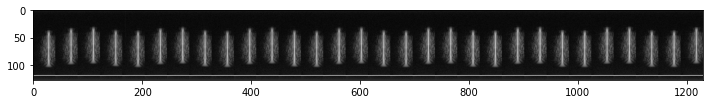

In [80]:
# Test all frames
coil = 5
framesm = np.abs(sp.ifft(frames, axes=(0,)))
framesr = sp.rss(framesm, axes=(2))
framesc = np.abs(frames[:,:,coil])

plt.figure(figsize=(12, 10))
plt.imshow(framesr**(1/3), cmap='gray')

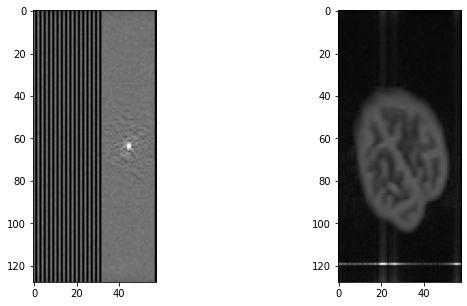

In [81]:
# Test single frame
curr_pass = 25
curr_xk = xk[:,:,curr_pass,:].squeeze()
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

xk_coil = np.abs(curr_xk[:,:,coil])
ax[0].imshow(xk_coil[:,:]**(1/3), cmap='gray');

xkm = np.abs(sp.ifft(curr_xk, axes=(0,1)))
xkr = sp.rss(xkm, axes=(2))
ax[1].imshow(xkr**(1/3), cmap='gray');

### Reconstruct image

In [59]:
import numpy as np

def zpad(x, *args):
    if len(args) < 1:
        raise ValueError('must have a target size')

    if len(args) == 1:
        s = args[0]
    elif len(args) == 2:
        s = (args[0], args[1])
    elif len(args) == 3:
        s = (args[0], args[1], args[2])
    elif len(args) == 4:
        s = (args[0], args[1], args[2], args[3])
    
    m = np.array(x.shape)
    if len(m) < len(s):
        m = np.append(m, np.ones(len(s) - len(m)))

    if np.array_equal(m, s):
        return x

    res = np.zeros(s)
    idx = [slice((s[n] - m[n]) // 2, (s[n] - m[n]) // 2 + m[n]) for n in range(len(s))]

    res[tuple(idx)] = x
    return res


def homodyneW(imSize, p):
    sx = imSize[1]
    sy = imSize[0]
    
    win = int((sx*p - sx/2) * 2)

    mask = zpad(np.ones((win, 1)), [sx,1])
    mask = np.cumsum(mask)
    mask = mask[::-1]
    mask = np.tile(mask[:, np.newaxis], [1,sy])
    mask = mask / mask[0] * 2

    phmask = zpad(np.tile(np.ones((win, 1)), (1, sy)), (sx, sy))

    return mask.T, phmask.T

def ssfse_recon(xk, archive, pe_pix_frac, frame=10, plot=False):
    # expand xk
    num_pe = int(xk.shape[1] / pe_pix_frac)
    full_xk = np.zeros((xk.shape[0], num_pe, xk.shape[2], xk.shape[3])) + 1j*np.zeros((xk.shape[0], num_pe, xk.shape[2], xk.shape[3]))
    full_xk[:,:xk.shape[1],:,:] = xk
    full_xk = full_xk.astype(np.complex64)

    # normalize xk to 98th percentile
    tmp = np.abs(sp.ifft(full_xk, axes=(0,1)))
    sorted_tmp = np.sort(tmp.flatten())
    xk_norm = full_xk / sorted_tmp[int(len(sorted_tmp) * 0.98)]

    # apply acceleration processing
    if archive.ParameterValue("ArcSamplingPattern") is not None:
        arc = Arc(archive.ArcParams())
        xk_norm = arc.Process(xk_norm)
    
    if plot: 
        plt.imshow(np.abs(xk_norm[:,:,frame,8])**(1/3),cmap='gray')
        plt.show()
        plt.imshow(sp.rss(np.abs(sp.ifft(xk_norm[:,:,frame,:],axes=(0,1))),axes=(2,))**(1/3),cmap='gray')
        plt.show()

    # homodyne processing
    mask, phmask = homodyneW([xk.shape[0],num_pe], xk.shape[1]/num_pe)
    xk_norm = xk_norm * mask[:, :, np.newaxis, np.newaxis]
    ph = sp.ifft(xk_norm * phmask[:, :, np.newaxis, np.newaxis], axes=(0,1))
    ph = np.exp(-1j * np.angle(ph))

    # make image
    im = np.real(sp.ifft(xk_norm, axes=(0,1)) * ph)[:,:,frame,:]
    im = sp.rss(im, axes=(2,))
    if plot:
        plt.figure()
        plt.imshow(im**(1/3),cmap='gray')
        plt.show()
    
    return im

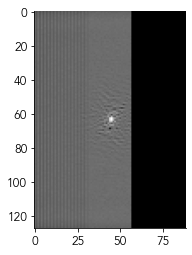

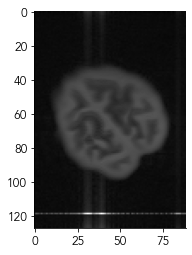

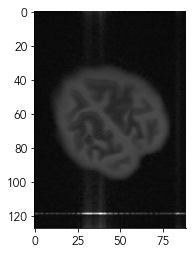

In [6]:
im = ssfse_recon(xk,archive,pe_pix_frac=phasefrac,frame=15,plot=True)

In [ ]:
ims = []
for frame in range(xk.shape[2]):
    im = ssfse_recon(xk, archive, pe_pix_frac=phasefrac, frame=frame, plot=False)
    ims.append(im)
ims = np.stack(ims, axis=2)

np.save('figures/exp_12_im', ims)

### BPT PCA processing

In [60]:
# Remove BPT from k-space

def squish_kspace(xk, tol=1e-5):
    zero_cols = np.all(np.abs(xk) < tol, axis=(0, 2, 3))
    xk_squish = xk[:, ~zero_cols, :, :]
    return xk_squish, zero_cols
    
def ssfse_bpt_processing(xk, frames, var_1=False, num_bpts=1, bpts=[]):
    # preprocess PCA input
    frames_norm_var = bp.normalize_variances(frames, var_1) # normalize
    framesr = bp.flatten(frames_norm_var, frames_norm_var.shape[0]) # flatten
    # get PCs
    pcs = bp.get_pcs(framesr) # each column is a PC (length nro)
    if len(bpts) > 0:
        bpt_pcs = pcs[:,bpts]
    else:
        bpt_pcs = pcs[:,:num_bpts] # (nro x # of BPTs)
        
    # preprocess xk
    xks, zero_cols = squish_kspace(xk) # remove 0-columns
    xkrs = bp.flatten(xks, xks.shape[0]) # flatten
    xkr = bp.flatten(xk, xk.shape[0])
    # extract BPT signals
    xbpts = bp.get_bpts(framesr, bpt_pcs) 
    # reconstruct k-space with the BPT PCs only
    x_rec = bpt_pcs @ bp.get_bpts(xkr, bpt_pcs) 
    
    # Reshape back: readouts x time x coils
    x_rec = np.reshape(x_rec, xk.shape)
    
    return xbpts, x_rec, bpt_pcs

In [35]:
xbpts, x_rec, bpt_pcs = ssfse_bpt_processing(xk, frames)
x_nobpt = xk - x_rec

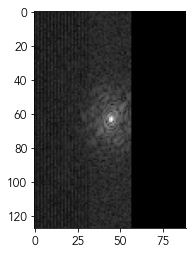

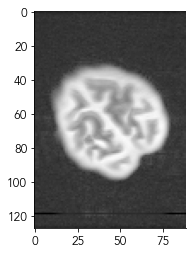

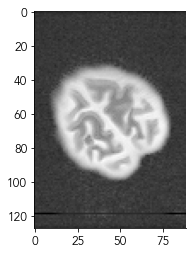

In [36]:
im_nobpt = ssfse_recon(x_nobpt,archive,phasefrac,frame=15,plot=True)

In [53]:
# isolate single coil in xbpts for Figure
xbpts_r = np.reshape(xbpts, (xbpts.shape[0], int(xbpts.shape[1]/num_channels), num_channels))
xbpts_onecoil = xbpts_r[:,:,1]

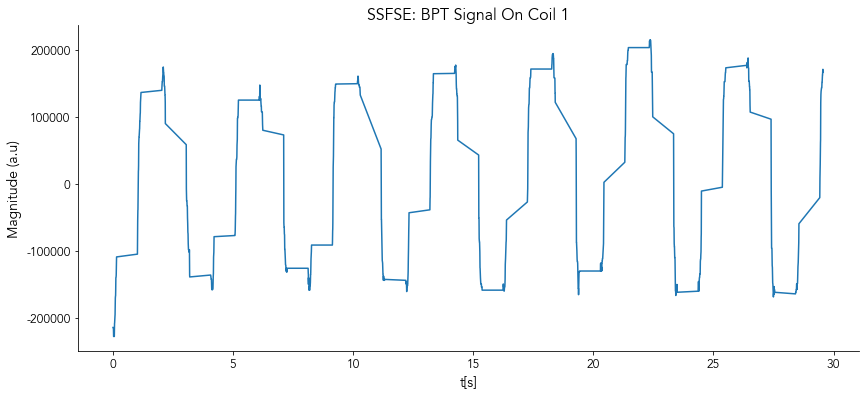

In [38]:
# Plot all plots
bpts = [0]
bpt_id = 0
offset = 1e6
# tr = 4e-3 # 4e-3
# bp.plot_bpt_pc(bpt_pcs, bpts)
# bp.plot_bpt_ifft(bpt_pcs, bpts)
t = np.loadtxt('t_vector.txt')/tr
t = t-t[0]
bp.plot_bpt(xbpts_onecoil, 1, bpt_id, t=t, offset=offset, filtering=50, tr=tr*1e-6, title=('SSFSE: BPT Signal On Coil 1'))

In [38]:
# make 3D reconstructed image (for gifs)

ims = []
for frame in range(x_nobpt.shape[2]):
    im = ssfse_recon(x_nobpt, archive, pe_pix_frac=phasefrac, frame=frame, plot=False)
    ims.append(im)
ims = np.stack(ims, axis=2)

np.save('figures/exp_12_im_nobpt_pca', ims)

### BPT Brackenier processing

In [ ]:
estimate = -1
edge_frac = 0.05
zero_pad_factor = 30

xk_br_filt = br.zeroed_withcroppingandpadding(xk, estimate=estimate, edge_frac=edge_frac, zero_pad_factor=zero_pad_factor)
xk_br_pfilt = br.zero_peak(xk, estimate=estimate)

In [64]:
# make 3D reconstructed image (for gifs)

ims = []
for frame in range(xk_br_filt.shape[2]):
    im = ssfse_recon(xk_br_filt, archive, pe_pix_frac=phasefrac, frame=frame, plot=False)
    ims.append(im)
ims = np.stack(ims, axis=2)

np.save('figures/exp_12_im_nobpt_brac', ims)

ims = []
for frame in range(xk_br_pfilt.shape[2]):
    im = ssfse_recon(xk_br_pfilt, archive, pe_pix_frac=phasefrac, frame=frame, plot=False)
    ims.append(im)
ims = np.stack(ims, axis=2)

np.save('figures/exp_12_im_nobpt_peak', ims)

### Make gif for figure

In [229]:
# Function to save frames as a GIF
def make_gif(xk, x_rec, archive, phasefrac, filename="bpt_removal_s12.gif", contrast_exp=1/3, clims=[0, 90], duration=0.2):
    # Make gif of all frames
    images = []

    # Loop over curr_pass from 0 to 28
    for curr_pass in range(xk.shape[2]):
        im = ssfse_recon(xk,archive,phasefrac,frame=curr_pass)
        im_nobpt = ssfse_recon(xk-x_rec,archive,phasefrac,frame=curr_pass)
        im_bpt = ssfse_recon(x_rec,archive,phasefrac,frame=curr_pass)

        # Create the plot
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))

        im0 = ax[0].imshow(im**(1/3), cmap='gray')
        im0.set_clim([np.percentile(im, clims[0]), np.percentile(im, clims[1])])
        ax[0].set_title("Original Image")
        ax[0].axis('off')
        plt.axis('off')

        im1 = ax[1].imshow(im_nobpt**(1/3), cmap='gray')
        im1.set_clim([np.percentile(im_nobpt, clims[0]), np.percentile(im_nobpt, clims[1])])
        ax[1].set_title("Image Without BPT")
        ax[1].axis('off')
        plt.axis('off')

        im2 = ax[2].imshow(im_bpt**(1/3), cmap='gray')
        im2.set_clim([np.percentile(im_bpt, clims[0]), np.percentile(im_bpt, clims[1])])
        ax[2].set_title("BPT")
        ax[2].axis('off')
        plt.axis('off')

        # Save the current frame to a buffer
        fig.canvas.draw()
        image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
        image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))

        # Append the image to the list
        images.append(image)

        # Close the figure to avoid memory issues
        plt.close(fig)

    # Save images as a GIF with tunable timing (duration per frame in seconds)
    imageio.mimsave(filename, images, duration=0.2)

# Example usage:
make_gif(xk, x_rec, archive, phasefrac, filename='bpt_removal_s12.gif', contrast_exp=1/3, duration=0.2)

In [196]:
# save xk for processing in BPT_processing.ipnyb
np.save("bpt_exp_s12.npy", xk)

## Series 13: Balance SSFP

### Fill k-space

In [80]:
# Load the archive
exam_num = 53019
series_num = 13

# Get largest .h5 file
archive_folder = os.path.join(os.path.abspath(''), "/mikLKS/bpt/data/pca_data/", f'Exam{exam_num}', f'Series{series_num}')
archive_files = [f for f in os.listdir(archive_folder) if f.endswith(".h5") and os.path.isfile(os.path.join(archive_folder, f))]
archive_filename = max(archive_files, key=lambda f: os.path.getsize(os.path.join(archive_folder, f))) if archive_files else None
archive_filename = os.path.join(archive_folder, archive_filename)
archive = Archive(archive_filename)

# Extract metadata
metadata = archive.Metadata()
x_res = metadata["acquiredXRes"]
y_res = metadata["acquiredYRes"]
num_control = metadata["controlCount"]
num_channels = metadata["numChannels"]
num_passes = metadata["passes"]
slices_per_pass = archive.SlicesPerPass()
# num_slices = metadata["slices"]
num_slices = slices_per_pass[0]

header = archive.Header()
bw = header['rdb_hdr_image']['vbw']
tr = header['rdb_hdr_image']['tr']
phasefrac = archive.ParameterValue("PhasePixelScaling")

# Extract header
print(metadata, f'number of slices per pass: {num_slices}, bw: {bw}, tr: {tr}, phasefrac: {phasefrac}')

{'acquiredXRes': 128, 'acquiredYRes': 46, 'controlCount': 6901, 'imageXRes': 256, 'imageYRes': 256, 'numChannels': 22, 'passes': 1, 'slices': 150} number of slices per pass: 150, bw: 62.5, tr: 5356.0, phasefrac: 0.699999988079071


In [66]:
pass_num = 0 # current pass number
archive = Archive(archive_filename)
kspace = np.zeros([x_res, y_res, num_channels, num_slices], dtype=np.complex64) # initializing k-space
frames = []

# Loop over all the control packets
for i in range(num_control):

    # Retrieve the next control packet
    control = archive.NextControl()

    # raw control packet; don't fill k-space
    if control["opcode"] == 16: 
        next_frame = np.squeeze(archive.NextFrame()) # keep control and frames in sync

    # programmable control packet
    # can fill the corresponding line of kspace
    elif control["opcode"] == 1 and 0 < control["viewNum"] <= y_res and control["sliceNum"] < num_slices:
        # frame data is organized as: ReadoutSize x NumChannels x NumFrames
        next_frame = np.squeeze(archive.NextFrame())
        # at control["viewNum"] (in y) and control["sliceNum"] (in slices) 
        kspace[:, control["viewNum"] - 1, :, control["sliceNum"]] = next_frame
        frames.append(next_frame)

    # scan control packet
    # can reconstruct the acquired data; not doing it here
    elif control["opcode"] == 0:

        # Receiving a scan control packet means that an acquisition finished,
        # so increase pass number and reset kspace to prepare for next acquisition (if it exists)
        pass_num += 1
        if pass_num < num_passes:
            num_slices = slices_per_pass[pass_num]
            kspace = np.zeros([x_res, y_res, num_channels, num_slices], dtype=np.complex64)
            
frames = np.array(frames).transpose(1,0,2)
xk = kspace.transpose(0,1,3,2)

### Test k-space filling

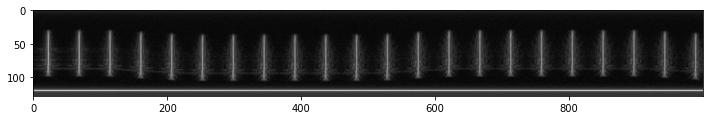

In [146]:
# Test all frames
coil = 5
framesm = np.abs(sp.ifft(frames, axes=(0,)))
framesr = sp.rss(framesm, axes=(2))
framesc = np.abs(frames[:,:,coil])

plt.figure(figsize=(12, 10))
plt.imshow(framesr[:,:1000]**(1/3), cmap='gray');

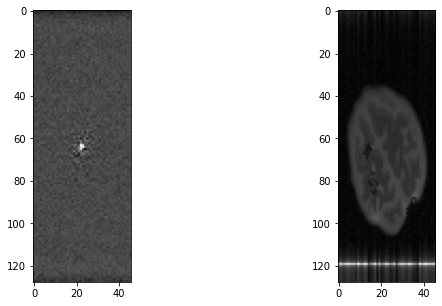

In [147]:
# Test single frame
curr_pass = 25
curr_xk = xk[:,:,curr_pass,:].squeeze()
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

xk_coil = np.abs(curr_xk[:,:,coil])
ax[0].imshow(xk_coil[:,:]**(1/3), cmap='gray');

xkm = np.abs(sp.ifft(curr_xk, axes=(0,1)))
xkr = sp.rss(xkm, axes=(2))
ax[1].imshow(xkr**(1/3), cmap='gray');

### Reconstruct image

In [67]:
import numpy as np

def zpad(x, *args):
    if len(args) < 1:
        raise ValueError('must have a target size')

    if len(args) == 1:
        s = args[0]
    elif len(args) == 2:
        s = (args[0], args[1])
    elif len(args) == 3:
        s = (args[0], args[1], args[2])
    elif len(args) == 4:
        s = (args[0], args[1], args[2], args[3])
    
    m = np.array(x.shape)
    if len(m) < len(s):
        m = np.append(m, np.ones(len(s) - len(m)))

    if np.array_equal(m, s):
        return x

    res = np.zeros(s) + 1j*np.zeros(s)
    idx = [slice((s[n] - m[n]) // 2, (s[n] - m[n]) // 2 + m[n]) for n in range(len(s))]

    res[tuple(idx)] = x
    return res

def ssfp_recon(xk, archive, pe_pix_frac, frame=10, plot=False):
    # apply acceleration processing
    if archive.ParameterValue("ArcSamplingPattern") is not None:
        arc = Arc(archive.ArcParams())
        xk = arc.Process(xk)
    
    # expand xk
    num_pe = int(xk.shape[1]/pe_pix_frac)
    full_xk = zpad(xk, xk.shape[0], num_pe, xk.shape[2], xk.shape[3])

    # normalize xk to 98th percentile
    tmp = np.abs(sp.ifft(full_xk, axes=(0,1)))
    sorted_tmp = np.sort(tmp.flatten())
    xk_norm = full_xk / sorted_tmp[int(len(sorted_tmp) * 0.98)]

    # make image
    im = np.abs(sp.ifft(xk_norm, axes=(0,1)))[:,:,frame,:]
    im = sp.rss(im, axes=(2,))
    if plot:
        plt.figure()
        plt.imshow(im**(1/3),cmap='gray')
        plt.show()
    
    return im

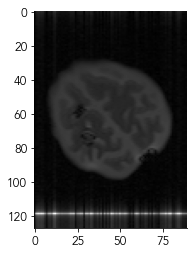

In [25]:
# TODO: fix
phasefrac = xk.shape[1]/90
im = ssfp_recon(xk,archive,phasefrac,frame=15,plot=True)

In [27]:
ims = []
for frame in range(xk.shape[2]):
    im = ssfp_recon(xk, archive, phasefrac, frame=frame, plot=False)
    ims.append(im)
ims = np.stack(ims, axis=2)

np.save('figures/exp_13_im', ims)

### BPT PCA Processing

In [42]:
# Remove BPT from k-space

def squish_kspace(xk, tol=1e-5):
    zero_cols = np.all(np.abs(xk) < tol, axis=(0, 2, 3))
    xk_squish = xk[:, ~zero_cols, :, :]
    return xk_squish, zero_cols
    
def ssfp_bpt_processing(xk, frames, var_1=False, num_bpts=1, bpts=[]):
    # preprocess PCA input
    frames_norm_var = bp.normalize_variances(frames, var_1) # normalize
    framesr = bp.flatten(frames_norm_var, frames_norm_var.shape[0]) # flatten
    # get PCs
    pcs = bp.get_pcs(framesr) # each column is a PC (length nro)
    if len(bpts) > 0:
        bpt_pcs = pcs[:,bpts]
    else:
        bpt_pcs = pcs[:,:num_bpts] # (nro x # of BPTs)
        
    # preprocess xk
    xkr = bp.flatten(xk, xk.shape[0])
    # extract BPT signals
    xbpts = bp.get_bpts(framesr, bpt_pcs) 
    # reconstruct k-space with the BPT PCs only
    x_rec = bpt_pcs @ bp.get_bpts(xkr, bpt_pcs)
    
    # Reshape back: readouts x time x coils
    x_rec = np.reshape(x_rec, xk.shape)
    
    return xbpts, x_rec, bpt_pcs

In [43]:
xbpts, x_rec, bpt_pcs = ssfp_bpt_processing(xk, frames)
x_nobpt = xk - x_rec

In [47]:
phasefrac = x_nobpt.shape[1]/90

ims = []
for frame in range(x_nobpt.shape[2]):
    im = ssfp_recon(x_nobpt, archive, phasefrac, frame=frame, plot=False)
    ims.append(im)
ims = np.stack(ims, axis=2)

np.save('figures/exp_13_im_nobpt_pca', ims)

In [59]:
# isolate single coil in xbpts for Figure
xbpts_r = np.reshape(xbpts, (xbpts.shape[0], int(xbpts.shape[1]/num_channels), num_channels))
xbpts_onecoil = xbpts_r[:,:,1]

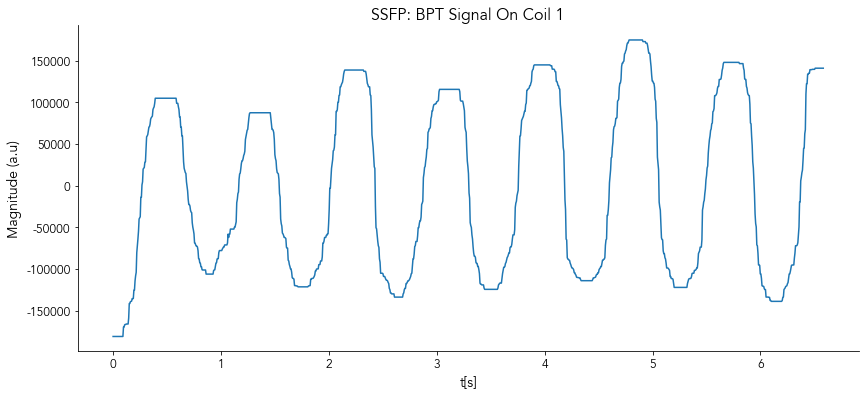

In [46]:
# Plot all plots
bpts = [0]
bpt_id = 0
offset = 1e6
# tr = 4e-3 # 4e-3
# bp.plot_bpt_pc(bpt_pcs, bpts)
# bp.plot_bpt_ifft(bpt_pcs, bpts)
bp.plot_bpt(xbpts_onecoil, 1, bpt_id, offset=offset, filtering=100, tr=tr*1e-6, title=('SSFP: BPT Signal On Coil 1'))

No handles with labels found to put in legend.


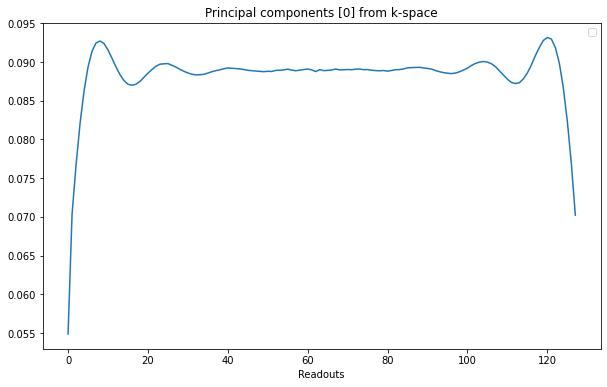

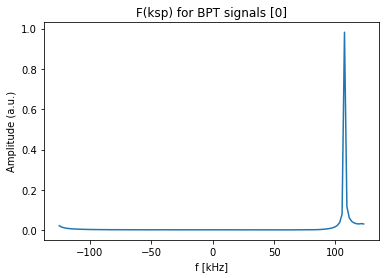

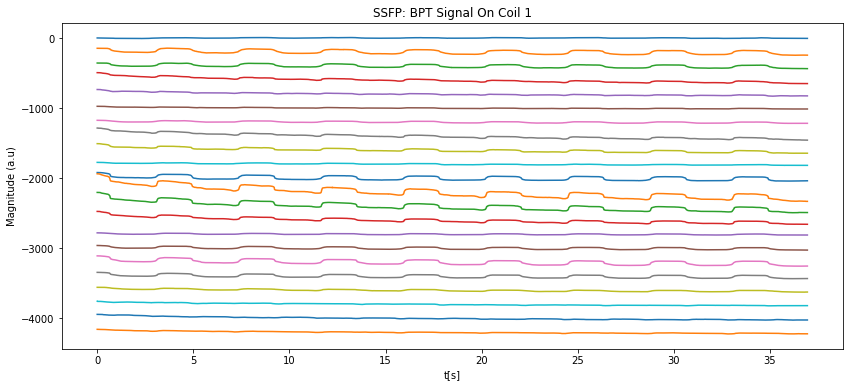

In [157]:
# Plot all plots
bpts = [0]
bpt_id = 0
offset = 2e2
bp.plot_bpt_pc(bpt_pcs, bpts)
bp.plot_bpt_ifft(bpt_pcs, bpts)
bp.plot_bpt(xbpts, num_channels, bpt_id, offset=offset, filtering=100, tr=tr*1e-6, title=('SSFP: BPT Signal On Coil 1'))

### BPT Brackenier processing

In [69]:
estimate = -1
edge_frac = 0.05
zero_pad_factor = 30

xk_br_filt = br.zeroed_withcroppingandpadding(xk, estimate=estimate, edge_frac=edge_frac, zero_pad_factor=zero_pad_factor)
xk_br_pfilt = br.zero_peak(xk, estimate=estimate)

In [74]:
# make 3D reconstructed image (for gifs)
phasefrac = xk_br_pfilt.shape[1]/90

# ims = []
# for frame in range(xk_br_filt.shape[2]):
#     im = ssfp_recon(xk_br_filt, archive, phasefrac, frame=frame, plot=False)
#     ims.append(im)
# ims = np.stack(ims, axis=2)

# np.save('figures/exp_13_im_nobpt_brac', ims)

ims = []
for frame in range(xk_br_pfilt.shape[2]):
    im = ssfse_recon(xk_br_pfilt, archive, pe_pix_frac=phasefrac, frame=frame, plot=False)
    ims.append(im)
ims = np.stack(ims, axis=2)

np.save('figures/exp_13_im_nobpt_peak', ims)

### Make gif for figure

In [ ]:
# Function to save frames as a GIF
def make_gif(xk, x_rec, archive, phasefrac, filename="bpt_removal_s13.gif", contrast_exp=1/3, clims=[0, 90], duration=0.2):
    # Make gif of all frames
    images = []

    # Loop over curr_pass from 0 to 28
    for curr_pass in range(xk.shape[2]):
        im = ssfp_recon(xk,archive,phasefrac,frame=curr_pass)
        im_nobpt = ssfp_recon(xk-x_rec,archive,phasefrac,frame=curr_pass)
        im_bpt = ssfp_recon(x_rec,archive,phasefrac,frame=curr_pass)

        # Create the plot
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))

        im0 = ax[0].imshow(im**(1/3), cmap='gray')
        im0.set_clim([np.percentile(im, clims[0]), np.percentile(im, clims[1])])
        ax[0].set_title("Original Image")
        ax[0].axis('off')
        plt.axis('off')

        im1 = ax[1].imshow(im_nobpt**(1/3), cmap='gray')
        im1.set_clim([np.percentile(im_nobpt, clims[0]), np.percentile(im_nobpt, clims[1])])
        ax[1].set_title("Image Without BPT")
        ax[1].axis('off')
        plt.axis('off')

        im2 = ax[2].imshow(im_bpt**(1/3), cmap='gray')
        im2.set_clim([np.percentile(im_bpt, clims[0]), np.percentile(im_bpt, clims[1])])
        ax[2].set_title("BPT")
        ax[2].axis('off')
        plt.axis('off')

        # Save the current frame to a buffer
        fig.canvas.draw()
        image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
        image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))

        # Append the image to the list
        images.append(image)

        # Close the figure to avoid memory issues
        plt.close(fig)

    # Save images as a GIF with tunable timing (duration per frame in seconds)
    imageio.mimsave(filename, images, duration=0.2)

# Example usage:
make_gif(xk, x_rec, archive, phasefrac, filename='bpt_removal_s13.gif', contrast_exp=1/3, duration=0.2)

In [ ]:
# save xk for processing in BPT_processing.ipnyb
np.save("bpt_exp_s13.npy", xk)

## Series 14: SSFSE, no acceleration

In [314]:
# Load the archive
exam_num = 53019
series_num = 14

# Get largest .h5 file
archive_folder = os.path.join(os.path.abspath(''), "/mikLKS/bpt/data/pca_data/", f'Exam{exam_num}', f'Series{series_num}')
archive_files = [f for f in os.listdir(archive_folder) if f.endswith(".h5") and os.path.isfile(os.path.join(archive_folder, f))]
archive_filename = max(archive_files, key=lambda f: os.path.getsize(os.path.join(archive_folder, f))) if archive_files else None
archive_filename = os.path.join(archive_folder, archive_filename)
archive = Archive(archive_filename)

# Extract metadata
metadata = archive.Metadata()
x_res = metadata["acquiredXRes"]
y_res = metadata["acquiredYRes"]
num_control = metadata["controlCount"]
num_channels = metadata["numChannels"]
num_passes = metadata["passes"]
slices_per_pass = archive.SlicesPerPass()
# num_slices = metadata["slices"]
num_slices = slices_per_pass[0]

header = archive.Header()
bw = header['rdb_hdr_image']['vbw']
tr = header['rdb_hdr_image']['tr']
phasefrac = archive.ParameterValue("ActualNumberOfExcitations")

# Extract header
print(metadata, f'number of slices per pass: {num_slices}, bw: {bw}, tr: {tr}, phasefrac: {phasefrac}')

{'acquiredXRes': 128, 'acquiredYRes': 54, 'controlCount': 1652, 'imageXRes': 256, 'imageYRes': 256, 'numChannels': 22, 'passes': 30, 'slices': 30} number of slices per pass: 1, bw: 83.33000183105469, tr: 1404564.0, phasefrac: 0.5869565010070801


In [315]:
archive = Archive(archive_filename)
pass_num = 0 # current pass number
kspace_all_passes = []
frames = []
kspace = np.zeros([x_res, y_res, num_channels, num_slices], dtype=np.complex64) # initializing k-space
apply_pure = False

# Loop over all the control packets
for i in range(num_control):

    # Retrieve the next control packet
    control = archive.NextControl()

    # raw control packet; don't fill k-space
    if control["opcode"] == 16: 
        next_frame = np.squeeze(archive.NextFrame()) # keep control and frames in sync

    # programmable control packet
    # can fill the corresponding line of kspace
    elif control["opcode"] == 1 and 0 < control["viewNum"] <= y_res and control["sliceNum"] < num_slices:
        # frame data is organized as: ReadoutSize x NumChannels x NumFrames
        next_frame = np.squeeze(archive.NextFrame())
        # at control["viewNum"] (in y) and control["sliceNum"] (in slices) 
        kspace[:, control["viewNum"] - 1, :, control["sliceNum"]] = next_frame
        frames.append(next_frame)

    # scan control packet
    # can reconstruct the acquired data; not doing it here
    elif control["opcode"] == 0:

        # Receiving a scan control packet means that an acquisition finished,
        # so increase pass number and reset kspace to prepare for next acquisition (if it exists)
        pass_num += 1
        if pass_num < num_passes:
            kspace_all_passes.append(kspace)
            num_slices = slices_per_pass[pass_num]
            kspace = np.zeros([x_res, y_res, num_channels, num_slices], dtype=np.complex64)

kspace_all_passes = np.array(kspace_all_passes)
frames = np.array(frames).transpose(1,0,2)
xk = kspace_all_passes.squeeze().transpose(1,2,0,3)
ncoils = xk.shape[3]

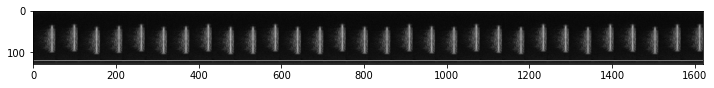

In [245]:
# Test all frames
coil = 5
framesm = np.abs(sp.ifft(frames, axes=(0,)))
framesr = sp.rss(framesm, axes=(2))
framesc = np.abs(frames[:,:,coil])

plt.figure(figsize=(12, 10))
plt.imshow(framesr**(1/3), cmap='gray')

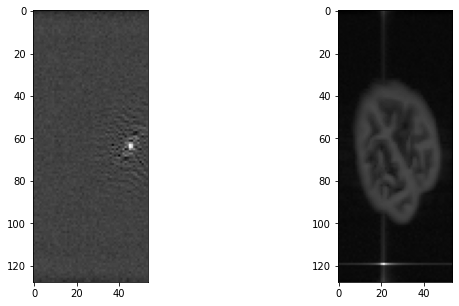

In [246]:
# Test single frame
curr_pass = 25
curr_xk = xk[:,:,curr_pass,:].squeeze()
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

xk_coil = np.abs(curr_xk[:,:,coil])
ax[0].imshow(xk_coil[:,:]**(1/3), cmap='gray');

xkm = np.abs(sp.ifft(curr_xk, axes=(0,1)))
xkr = sp.rss(xkm, axes=(2))
ax[1].imshow(xkr**(1/3), cmap='gray');

In [247]:
import numpy as np

def zpad(x, *args):
    if len(args) < 1:
        raise ValueError('must have a target size')

    if len(args) == 1:
        s = args[0]
    elif len(args) == 2:
        s = (args[0], args[1])
    elif len(args) == 3:
        s = (args[0], args[1], args[2])
    elif len(args) == 4:
        s = (args[0], args[1], args[2], args[3])
    
    m = np.array(x.shape)
    if len(m) < len(s):
        m = np.append(m, np.ones(len(s) - len(m)))

    if np.array_equal(m, s):
        return x

    res = np.zeros(s)
    idx = [slice((s[n] - m[n]) // 2, (s[n] - m[n]) // 2 + m[n]) for n in range(len(s))]

    res[tuple(idx)] = x
    return res


def homodyneW(imSize, p):
    sx = imSize[1]
    sy = imSize[0]
    
    win = int((sx*p - sx/2) * 2)

    mask = zpad(np.ones((win, 1)), [sx,1])
    mask = np.cumsum(mask)
    mask = mask[::-1]
    mask = np.tile(mask[:, np.newaxis], [1,sy])
    mask = mask / mask[0] * 2

    phmask = zpad(np.tile(np.ones((win, 1)), (1, sy)), (sx, sy))

    return mask.T, phmask.T

def ssfse_recon(xk, archive, pe_pix_frac, frame=10, plot=False):
    # expand xk
    num_pe = int(xk.shape[1] / pe_pix_frac)
    full_xk = np.zeros((xk.shape[0], num_pe, xk.shape[2], xk.shape[3])) + 1j*np.zeros((xk.shape[0], num_pe, xk.shape[2], xk.shape[3]))
    full_xk[:,:xk.shape[1],:,:] = xk
    full_xk = full_xk.astype(np.complex64)

    # normalize xk to 98th percentile
    tmp = np.abs(sp.ifft(full_xk, axes=(0,1)))
    sorted_tmp = np.sort(tmp.flatten())
    xk_norm = full_xk / sorted_tmp[int(len(sorted_tmp) * 0.98)]

    # apply acceleration processing
    if archive.ParameterValue("ArcSamplingPattern") is not None:
        arc = Arc(archive.ArcParams())
        xk_norm = arc.Process(xk_norm)
    
    if plot: 
        plt.imshow(np.abs(xk_norm[:,:,frame,8])**(1/3),cmap='gray')
        plt.show()
        plt.imshow(sp.rss(np.abs(sp.ifft(xk_norm[:,:,frame,:],axes=(0,1))),axes=(2,))**(1/3),cmap='gray')
        plt.show()

    # homodyne processing
    mask, phmask = homodyneW([xk.shape[0],num_pe], xk.shape[1]/num_pe)
    xk_norm = xk_norm * mask[:, :, np.newaxis, np.newaxis]
    ph = sp.ifft(xk_norm * phmask[:, :, np.newaxis, np.newaxis], axes=(0,1))
    ph = np.exp(-1j * np.angle(ph))

    # make image
    im = np.real(sp.ifft(xk_norm, axes=(0,1)) * ph)[:,:,frame,:]
    im = sp.rss(im, axes=(2,))
    if plot:
        plt.figure()
        plt.imshow(im**(1/3),cmap='gray')
        plt.show()
    
    return im

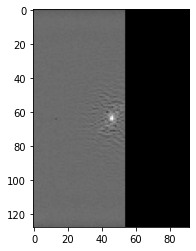

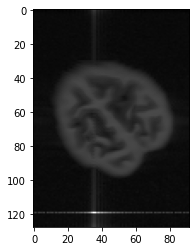

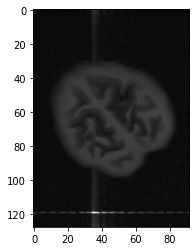

In [248]:
im = ssfse_recon(xk,archive,pe_pix_frac=phasefrac,frame=15,plot=True)

In [249]:
# Remove BPT from k-space

def squish_kspace(xk, tol=1e-5):
    zero_cols = np.all(np.abs(xk) < tol, axis=(0, 2, 3))
    xk_squish = xk[:, ~zero_cols, :, :]
    return xk_squish, zero_cols
    
def ssfse_bpt_processing(xk, frames, var_1=False, num_bpts=1, bpts=[]):
    # preprocess PCA input
    frames_norm_var = bp.normalize_variances(frames, var_1) # normalize
    framesr = bp.flatten(frames_norm_var, frames_norm_var.shape[0]) # flatten
    # get PCs
    pcs = bp.get_pcs(framesr) # each column is a PC (length nro)
    if len(bpts) > 0:
        bpt_pcs = pcs[:,bpts]
    else:
        bpt_pcs = pcs[:,:num_bpts] # (nro x # of BPTs)
        
    # preprocess xk
    xks, zero_cols = squish_kspace(xk) # remove 0-columns
    xkrs = bp.flatten(xks, xks.shape[0]) # flatten
    xkr = bp.flatten(xk, xk.shape[0])
    # extract BPT signals
    xbpts = bp.get_bpts(framesr, bpt_pcs) 
    # reconstruct k-space with the BPT PCs only
    x_rec = bpt_pcs @ bp.get_bpts(xkr, bpt_pcs) 
    
    # Reshape back: readouts x time x coils
    x_rec = np.reshape(x_rec, xk.shape)
    
    return xbpts, x_rec, bpt_pcs

In [316]:
xbpts, x_rec, bpt_pcs = ssfse_bpt_processing(xk, frames)
x_nobpt = xk - x_rec

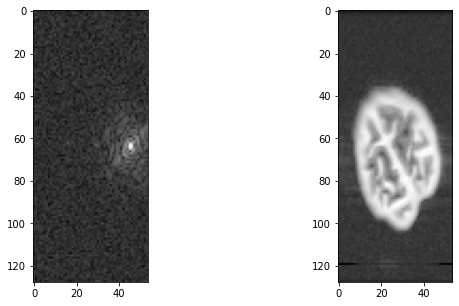

In [251]:
# Test single frame: remove BPT
curr_pass = 8
curr_x_rec = x_nobpt[:,:,curr_pass,:].squeeze()
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

x_rec_coil = np.abs(curr_x_rec[:,:,coil])
ax[0].imshow(x_rec_coil[:,:]**(1/3), cmap='gray');

x_rec_m = np.abs(sp.ifft(curr_x_rec, axes=(0,1)))
x_rec_r = sp.rss(x_rec_m, axes=(2))
ax[1].imshow(x_rec_r**(1/3), cmap='gray');

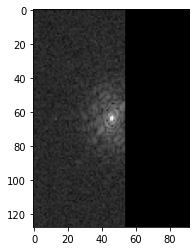

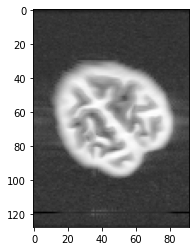

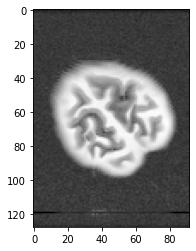

In [252]:
im_nobpt = ssfse_recon(x_nobpt,archive,phasefrac,frame=15,plot=True)

No handles with labels found to put in legend.


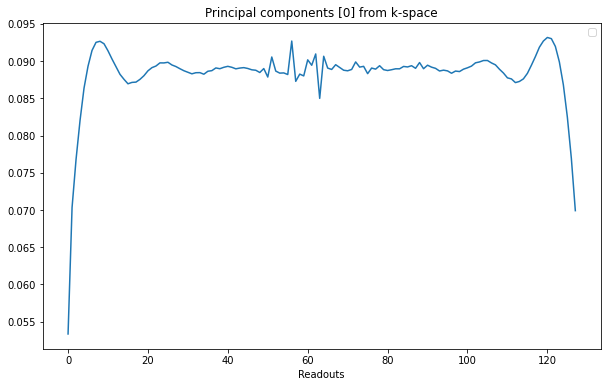

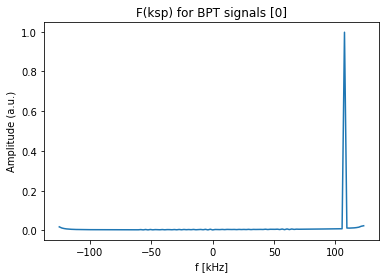

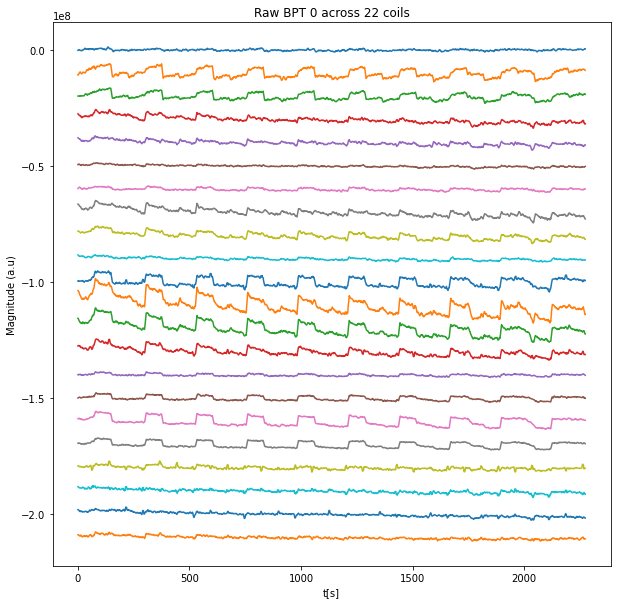

In [317]:
# Plot all plots
bpts = [0]
bpt_id = 0
offset = 1e7
bp.plot_bpt_pc(bpt_pcs, bpts)
bp.plot_bpt_ifft(bpt_pcs, bpts)
bp.plot_bpt(xbpts, ncoils, bpt_id, offset=offset, filtering=5, tr=tr*1e-6)

In [255]:
# Function to save frames as a GIF
def make_gif(xk, x_rec, archive, phasefrac, filename="bpt_removal_s14.gif", contrast_exp=1/3, clims=[0, 90], duration=0.2):
    # Make gif of all frames
    images = []

    # Loop over curr_pass from 0 to 28
    for curr_pass in range(xk.shape[2]):
        im = ssfse_recon(xk,archive,phasefrac,frame=curr_pass)
        im_nobpt = ssfse_recon(xk-x_rec,archive,phasefrac,frame=curr_pass)
        im_bpt = ssfse_recon(x_rec,archive,phasefrac,frame=curr_pass)

        # Create the plot
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))

        im0 = ax[0].imshow(im**(1/3), cmap='gray')
        im0.set_clim([np.percentile(im, clims[0]), np.percentile(im, clims[1])])
        ax[0].set_title("Original Image")
        ax[0].axis('off')
        plt.axis('off')

        im1 = ax[1].imshow(im_nobpt**(1/3), cmap='gray')
        im1.set_clim([np.percentile(im_nobpt, clims[0]), np.percentile(im_nobpt, clims[1])])
        ax[1].set_title("Image Without BPT")
        ax[1].axis('off')
        plt.axis('off')

        im2 = ax[2].imshow(im_bpt**(1/3), cmap='gray')
        im2.set_clim([np.percentile(im_bpt, clims[0]), np.percentile(im_bpt, clims[1])])
        ax[2].set_title("BPT")
        ax[2].axis('off')
        plt.axis('off')

        # Save the current frame to a buffer
        fig.canvas.draw()
        image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
        image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))

        # Append the image to the list
        images.append(image)

        # Close the figure to avoid memory issues
        plt.close(fig)

    # Save images as a GIF with tunable timing (duration per frame in seconds)
    imageio.mimsave(filename, images, duration=0.2)

# Example usage:
make_gif(xk, x_rec, archive, phasefrac, filename='bpt_removal_s14.gif', contrast_exp=1/3, duration=0.2)

In [196]:
# save xk for processing in BPT_processing.ipnyb
np.save("bpt_exp_s12.npy", xk)